# 🎨 Acervo Portinari — Visualizações Interativas
> Inspirado no [Vikus Viewer](https://vikusviewer.fh-potsdam.de/) — exploração visual e temporal de acervos culturais.

**Instale as dependências antes de rodar:**
```bash
pip install pandas plotly ipywidgets wordcloud matplotlib Pillow kaleido
```

---
## 0. Setup — carregamento e limpeza

In [2]:
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from IPython.display import display, HTML
import ipywidgets as widgets
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')


# ── Caminhos ────────────────────────────────────────────────────────
OBRAS_JSON    = Path('../Data/obras_limpo.json')
PASTA_IMAGENS = Path('../Data/imagens')

# ── Carrega ─────────────────────────────────────────────────────────
with open(OBRAS_JSON, encoding='utf-8') as f:
    obras = json.load(f)
df = pd.DataFrame(obras)

# ── Limpeza ─────────────────────────────────────────────────────────
def extrair_ano(texto):
    if not isinstance(texto, str): return None
    m = re.search(r'\d{4}', texto)
    return int(m.group()) if m else None

df['ano']    = df['dataTexto'].apply(extrair_ano)
df['altura'] = pd.to_numeric(df.get('altura'), errors='coerce')
df['largura'] = pd.to_numeric(df.get('largura'), errors='coerce')
df['area_cm2'] = df['altura'] * df['largura']
df['decada']  = (df['ano'] // 10 * 10).astype('Int64')

# Listas → string
for col in ['temas', 'pessoasRetratadas']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: ', '.join(x) if isinstance(x, list) else (x or ''))

df['tecnica']  = df.get('tecnica',  pd.Series()).fillna('não informada')
df['suporte']  = df.get('suporte',  pd.Series()).fillna('não informado')
df['tipoObra'] = df.get('tipoObra', pd.Series()).fillna('não informado')
df['tem_imagem'] = df['imagemLocal'].notna()

print(f'✅ {len(df)} obras carregadas | {df["tem_imagem"].sum()} com imagem')
print(f'   Anos: {int(df["ano"].min())} – {int(df["ano"].max())}')
df.head(3)

✅ 1826 obras carregadas | 1807 com imagem
   Anos: 1920 – 1962


,id,obraUrl,titulo,codigoFCO,numeroCR,dataTexto,imagemUrl,descricaoResumida,descricaoCompleta,localProducao,...,inscricaoFamilia,inscricaoExposicao,dimensoes,temas,pessoasRetratadas,imagemLocal,ano,decada,area_cm2,tem_imagem
0,14686,https://www.portinari.org.br/acervo/obras/1468...,Autorretrato,FCO-1,CR-4093,[1957],https://acervo-portinari.s3.sa-east-1.amazonaw...,"Composição nos tons claro de ocres, cinza e az...","Composição nos tons claro de ocres, cinza e az...",Brasil > São Paulo > Brodowski > Brasil > Rio ...,...,"No verso, inscrição de Maria Portinari “ON 994”.",None,"29,5 x 21 cm","Retrato, Autorretrato, Figura Humana, Homem",Candido Portinari,14686_Autorretrato.jpeg,1957.0,1950,NaN,True
1,14701,https://www.portinari.org.br/acervo/obras/1470...,Autorretrato,FCO-2,CR-967,1939,https://acervo-portinari.s3.sa-east-1.amazonaw...,"Composição nos tons terras, cinzas, preto, ama...","Composição nos tons terras, cinzas, preto, ama...",Brasil > Rio de Janeiro > Rio de Janeiro,...,"No verso, inscrição de Maria Portinari “ON 986”.",None,42 x 35 cm,"Retrato, Autorretrato, Figura Humana, Homem",Candido Portinari,14701_Autorretrato.jpeg,1939.0,1930,1470.0,True
2,14715,https://www.portinari.org.br/acervo/obras/1471...,Autorretrato,FCO-3,CR-4094,1957,https://acervo-portinari.s3.sa-east-1.amazonaw...,"Composição nos tons ocres, terras, brancos, az...","Composição nos tons ocres, terras, brancos, az...",Brasil > São Paulo > Brodowski,...,"No verso, inscrição de Maria Portinari “ON 995A”.","No verso, inscrição “Nº 20 Milão”; etiquetas “...",54 x 45 cm,"Retrato, Autorretrato, Figura Humana, Homem",Candido Portinari,14715_Autorretrato.jpeg,1957.0,1950,2430.0,True


---
## 1. 🕐 Timeline — Obras no Tempo *(estilo Vikus Viewer)*

Cada ponto é uma obra. O eixo X é o ano, o tamanho reflete a área da pintura e a cor indica a técnica.

In [3]:
df_timeline = df.dropna(subset=['ano']).copy()

# Distribui obras do mesmo ano verticalmente para evitar sobreposição
df_timeline = df_timeline.sort_values('ano')
df_timeline['jitter'] = df_timeline.groupby('ano').cumcount()
df_timeline['y_pos']  = df_timeline['jitter'] - df_timeline.groupby('ano')['jitter'].transform('max') / 2

# Tamanho proporcional à área (normalizado)
area = df_timeline['area_cm2'].fillna(df_timeline['area_cm2'].median())
tamanho = ((area - area.min()) / (area.max() - area.min()) * 20 + 5).clip(5, 25)

fig = px.scatter(
    df_timeline,
    x='ano',
    y='y_pos',
    color='tecnica',
    size=tamanho,
    size_max=20,
    hover_name='titulo',
    hover_data={
        'ano': True,
        'tecnica': True,
        'suporte': True,
        'dimensoes': True,
        'y_pos': False,
    },
    title='📅 Linha do Tempo das Obras de Portinari',
    labels={'ano': 'Ano', 'y_pos': '', 'tecnica': 'Técnica'},
    template='plotly_white',
    height=520,
)

fig.update_layout(
    yaxis=dict(showticklabels=False, showgrid=False, zeroline=False),
    xaxis=dict(showgrid=True, gridcolor='#eee'),
    legend_title='Técnica',
    font=dict(family='Georgia, serif', size=13),
    title_font_size=18,
    plot_bgcolor='#fafafa',
)
fig.show()

---
## 2. 📊 Painel de Estatísticas — 4 gráficos em grade

In [4]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Obras por Década',
        'Técnicas mais usadas',
        'Suportes mais usados',
        'Distribuição de Área (cm²)',
    ),
    vertical_spacing=0.18,
    horizontal_spacing=0.12,
)

COR = px.colors.qualitative.Antique

# ── Obras por década ────────────────────────────────────────────────
dec = df['decada'].value_counts().sort_index().reset_index()
dec.columns = ['decada', 'count']
fig.add_trace(go.Bar(
    x=dec['decada'].astype(str) + 's',
    y=dec['count'],
    marker_color=COR,
    name='Década',
    showlegend=False,
), row=1, col=1)

# ── Técnicas ────────────────────────────────────────────────────────
tec = df['tecnica'].value_counts().head(8).reset_index()
tec.columns = ['tecnica', 'count']
fig.add_trace(go.Bar(
    x=tec['count'],
    y=tec['tecnica'],
    orientation='h',
    marker_color=COR[2],
    name='Técnica',
    showlegend=False,
), row=1, col=2)

# ── Suportes ────────────────────────────────────────────────────────
sup = df['suporte'].value_counts().head(8).reset_index()
sup.columns = ['suporte', 'count']
fig.add_trace(go.Bar(
    x=sup['count'],
    y=sup['suporte'],
    orientation='h',
    marker_color=COR[4],
    name='Suporte',
    showlegend=False,
), row=2, col=1)

# ── Distribuição de área ─────────────────────────────────────────────
area_vals = df['area_cm2'].dropna()
fig.add_trace(go.Histogram(
    x=area_vals,
    nbinsx=30,
    marker_color=COR[6],
    name='Área',
    showlegend=False,
), row=2, col=2)

fig.update_layout(
    height=680,
    title_text='📊 Estatísticas do Acervo Portinari',
    title_font_size=18,
    font=dict(family='Georgia, serif', size=12),
    plot_bgcolor='#fafafa',
    paper_bgcolor='white',
)
fig.show()

---
## 3. 📐 Proporções — Largura × Altura por Técnica

Visualiza o formato físico de cada obra. Pinte os pontos pela técnica para ver padrões.

In [5]:
df_dim = df.dropna(subset=['altura', 'largura']).copy()

fig = px.scatter(
    df_dim,
    x='largura',
    y='altura',
    color='tecnica',
    hover_name='titulo',
    hover_data={'ano': True, 'dimensoes': True, 'largura': False, 'altura': False},
    title='📐 Dimensões Físicas das Obras (cm)',
    labels={'largura': 'Largura (cm)', 'altura': 'Altura (cm)', 'tecnica': 'Técnica'},
    template='plotly_white',
    height=500,
    opacity=0.75,
)

# Linha diagonal = obras quadradas
lim = max(df_dim['largura'].max(), df_dim['altura'].max())
fig.add_shape(type='line', x0=0, y0=0, x1=lim, y1=lim,
              line=dict(color='gray', dash='dot', width=1))
fig.add_annotation(x=lim*0.85, y=lim*0.9, text='formato quadrado',
                   showarrow=False, font=dict(color='gray', size=10))

fig.update_layout(
    font=dict(family='Georgia, serif', size=13),
    title_font_size=18,
)
fig.show()

---
## 4. 🔤 Nuvem de Palavras das Descrições

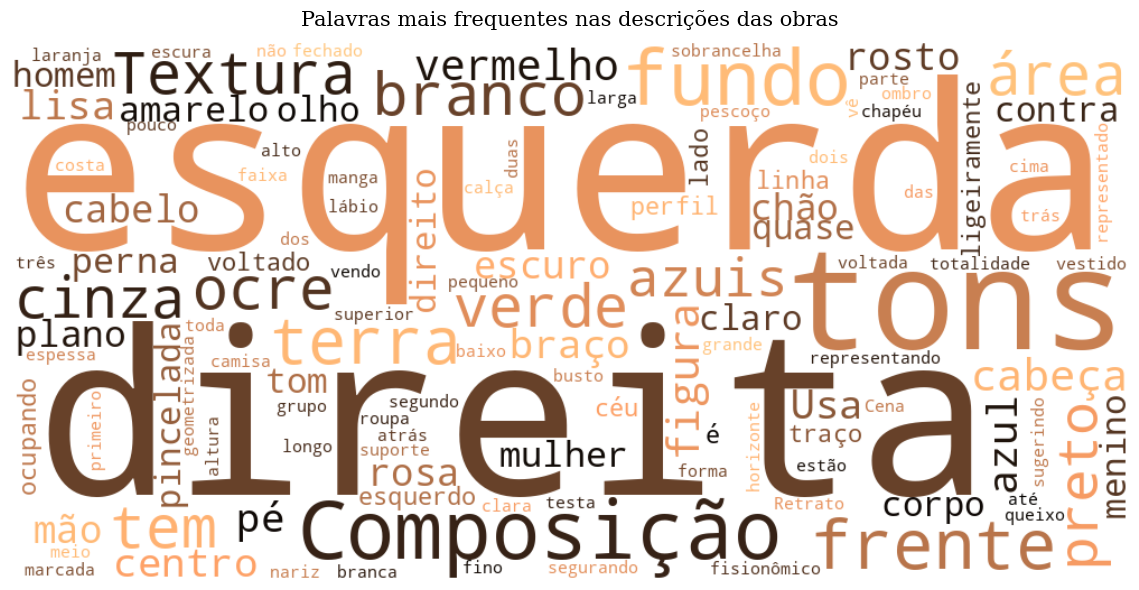

In [9]:
from wordcloud import WordCloud, STOPWORDS

col_descricao = 'descricaoCompleta' if 'descricaoCompleta' in df.columns else 'descricaoResumida'
texto = ' '.join(df[col_descricao].dropna().tolist())

# Stopwords em português
stopwords_pt = STOPWORDS | {
    'de', 'da', 'do', 'em', 'e', 'o', 'a', 'os', 'as', 'um', 'uma',
    'com', 'para', 'por', 'no', 'na', 'nos', 'nas', 'se', 'que',
    'ao', 'à', 'aos', 'às', 'ou', 'seu', 'sua', 'seus', 'suas',
    'está', 'são', 'foi', 'sendo', 'sobre', 'entre', 'mais'
}

wc = WordCloud(
    width=1000, height=480,
    background_color='white',
    colormap='copper',          # tons que remetem a telas e pigmentos
    stopwords=stopwords_pt,
    max_words=120,
    collocations=False,
    font_path=None,             # usa a fonte padrão do sistema
).generate(texto)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Palavras mais frequentes nas descrições das obras', fontsize=15, pad=12, fontfamily='serif')
plt.tight_layout()
plt.show()

---
## 5. 🖼️ Grade Visual Interativa com Filtros

Filtre por técnica e/ou intervalo de anos e veja as pinturas em grade.

In [11]:
from IPython.display import display, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

PASTA_IMAGENS = Path('../Data/imagens')
df_img = df[df['tem_imagem']].dropna(subset=['ano']).copy()

tecnicas_disponiveis = sorted(df_img['tecnica'].unique().tolist())
ano_min, ano_max = int(df_img['ano'].min()), int(df_img['ano'].max())

# ── Widgets ──────────────────────────────────────────────────────────
w_tecnica = widgets.SelectMultiple(
    options=['todas'] + tecnicas_disponiveis,
    value=['todas'],
    description='Técnica:',
    layout=widgets.Layout(height='120px', width='280px'),
)
w_anos = widgets.IntRangeSlider(
    value=[ano_min, ano_max], min=ano_min, max=ano_max,
    step=1, description='Anos:',
    layout=widgets.Layout(width='460px'),
)
w_colunas = widgets.IntSlider(
    value=5, min=2, max=8, description='Colunas:',
    layout=widgets.Layout(width='300px'),
)
w_limite = widgets.IntSlider(
    value=20, min=5, max=60, step=5, description='Mostrar:',
    layout=widgets.Layout(width='300px'),
)
btn = widgets.Button(
    description='🔍 Aplicar filtros',
    button_style='primary',
    layout=widgets.Layout(width='180px', height='36px'),
)
saida = widgets.Output()

def exibir_grade(_):
    with saida:
        clear_output(wait=True)

        # Filtra
        mascara = (df_img['ano'] >= w_anos.value[0]) & (df_img['ano'] <= w_anos.value[1])
        if 'todas' not in w_tecnica.value:
            mascara &= df_img['tecnica'].isin(w_tecnica.value)
        selecionadas = df_img[mascara].sort_values('ano').head(w_limite.value)

        print(f'🎨 {len(selecionadas)} obras exibidas ({len(df_img[mascara])} encontradas com filtro)')

        if selecionadas.empty:
            print('Nenhuma obra encontrada com esses filtros.')
            return

        ncols = w_colunas.value
        nrows = -(-len(selecionadas) // ncols)  # ceil division
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.2))
        axes = np.array(axes).flatten()

        for i, (_, obra) in enumerate(selecionadas.iterrows()):
            caminho = PASTA_IMAGENS / obra['imagemLocal']
            if caminho.exists():
                img = mpimg.imread(caminho)
                axes[i].imshow(img)
            else:
                axes[i].set_facecolor('#eee')
                axes[i].text(0.5, 0.5, '?', ha='center', va='center', fontsize=20, color='#aaa')

            titulo = (obra['titulo'] or '')[:22] + ('…' if len(obra['titulo'] or '') > 22 else '')
            axes[i].set_title(f"{titulo}\n{int(obra['ano'])}", fontsize=7.5, pad=3)
            axes[i].axis('off')

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(
            f'Acervo Portinari — {w_anos.value[0]}–{w_anos.value[1]}',
            fontsize=13, fontfamily='serif', y=1.01
        )
        plt.tight_layout()

        # Salva a grade automaticamente
        '''nome = f"grade_{w_anos.value[0]}_{w_anos.value[1]}.png"
        plt.savefig(nome, dpi=130, bbox_inches='tight')'''
        plt.show()
        '''print(f'💾 Grade salva em {nome}')'''

btn.on_click(exibir_grade)

painel = widgets.VBox([
    widgets.HTML('<b style="font-size:15px">🎛️ Filtros</b>'),
    widgets.HBox([w_tecnica, widgets.VBox([w_anos, w_colunas, w_limite])]),
    btn,
    saida,
])
display(painel)
exibir_grade(None)  # Exibe sem filtros ao abrir

---
## 6. 📈 Evolução Temporal por Técnica

Como a produção de Portinari em cada técnica variou ao longo dos anos?

In [ ]:
df_evol = df.dropna(subset=['ano', 'tecnica']).copy()
df_evol['decada'] = (df_evol['ano'] // 10 * 10).astype(int)

# Considera só as 6 técnicas mais frequentes
top_tecnicas = df_evol['tecnica'].value_counts().head(6).index.tolist()
df_evol = df_evol[df_evol['tecnica'].isin(top_tecnicas)]

pivot = (
    df_evol.groupby(['decada', 'tecnica'])
    .size()
    .reset_index(name='quantidade')
)

fig = px.line(
    pivot,
    x='decada', y='quantidade', color='tecnica',
    markers=True,
    title='📈 Produção por Técnica ao Longo das Décadas',
    labels={'decada': 'Década', 'quantidade': 'Nº de Obras', 'tecnica': 'Técnica'},
    template='plotly_white',
    height=450,
)
fig.update_traces(line=dict(width=2.5), marker=dict(size=8))
fig.update_layout(
    font=dict(family='Georgia, serif', size=13),
    title_font_size=18,
    xaxis=dict(dtick=10),
)
fig.show()

---
## 7. 💾 Exportar gráficos para o relatório (PNG / HTML)

In [ ]:
# Salva os gráficos Plotly como imagem estática (para Word/PDF)
# Requer: pip install kaleido

from pathlib import Path
Path('graficos').mkdir(exist_ok=True)

graficos = {
    'timeline':   fig,       # substitua pelas variáveis corretas se renomear
    'evolucao':   fig,
}

# Maneira recomendada: reexecute cada figura e salve logo após
# Exemplo:
#   fig_timeline.write_image('output/graficos/timeline.png', scale=2)
#   fig_timeline.write_html('output/graficos/timeline.html')   # versão interativa

print('Dica: após cada célula de gráfico, salve assim:')
print('  fig.write_image("output/graficos/nome.png", scale=2)   # PNG estático')
print('  fig.write_html("output/graficos/nome.html")            # HTML interativo')